# 🌿 Analisis & Prediksi Produksi Tebu Indonesia
**Author:** Reisha Narindra Whibangga
**Dataset:** FAOSTAT, BPS, Kementan Outlook Tebu 2023  
**Tujuan:** Eksplorasi data historis produksi tebu Indonesia dan prediksi produksi beberapa tahun ke depan

# Landasan Dasar
- Menggunakan metode SARIMA (Seasonal AutoRegressive Integrated Moving Average) oleh George Box dan Gwilym Jenkins.
- Anatomi rumus SARIMA(p,d,q) : Ŷ(t) = c + φ₁·Y(t-1) + ... + φₚ·Y(t-p) − θ₁·ε(t-1) − ... − θq·ε(t-q) + ε(t)
**Penjelasan**
1. AR(p) — AutoRegresif φ₁·Y(t-1) + φₚ·Y(t-p) Nilai masa lalu memengaruhi sekarang
2. I(d) — Differencing ΔY(t) = Y(t) − Y(t-1) Membuat data stasioner (d=1)
3. MA(q) — Moving Avg θ₁·ε(t-1) + θq·ε(t-q) Error masa lalu dikoreksi sekarang
**Parameter model : SARIMA (1,1,1)**
1. p = 1 Gunakan 1 nilai masa lalu sebagai prediktor
2. d = 1 Differencing 1x karena ADF test: p=0.9846
3. q = 1 Koreksi dari 1 error periode sebelumnya

**Proses prediksi**
1. Data asli Y(2013–2024)
2. Differencing d=1, stasioner
3. Fit ARMA AR(1) + MA(1)
4. Prediksi 10 tahun ke depan + interval 95%
**Dari model yang diuji pada data 2022-2024 sebelum digunakan untuk prediksi 2025-2034 Diharapkan mendapatkan hasil evaluasi MAPE = 2,39% - akurasi sangat baik (<10%), sehingga dapat memprediksi produksi beberapa tahun ke depan.**
---
## 📋 Alur Notebook
1. Load & preview semua dataset
2. Data cleaning & standarisasi
3. Exploratory Data Analysis (EDA)
4. Forecasting produksi (SARIMA / Prophet)
5. Visualisasi hasil prediksi

## 📦 1. Import Library

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='Set2')

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


## 📂 2. Load Dataset


### 2.1 FAOSTAT — Data Produksi Global (termasuk Indonesia)

In [21]:
# Load FAOSTAT CSV
fao_df = pd.read_csv('../data/raw/FAOSTAT_data_en_3-14-2026(1).csv')

print('Shape:', fao_df.shape)
print('Kolom:', fao_df.columns.tolist())
fao_df.head()

Shape: (33, 15)
Kolom: ['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,360,Indonesia,5312,Area harvested,1802,Sugar cane,2013,2013,ha,470941.0,A,Official figure,NaN
1,QCL,Crops and livestock products,360,Indonesia,5412,Yield,1802,Sugar cane,2013,2013,kg/ha,60304.8,E,Estimated value,NaN
2,QCL,Crops and livestock products,360,Indonesia,5510,Production,1802,Sugar cane,2013,2013,t,28400000.0,X,Figure from external organization,Unofficial figure
3,QCL,Crops and livestock products,360,Indonesia,5312,Area harvested,1802,Sugar cane,2015,2015,ha,455819.0,A,Official figure,NaN
4,QCL,Crops and livestock products,360,Indonesia,5412,Yield,1802,Sugar cane,2015,2015,kg/ha,59234.0,E,Estimated value,NaN


In [22]:
# Filter hanya data Indonesia
fao_indo = fao_df[fao_df['Area'] == 'Indonesia'].copy()

print(f'Jumlah baris Indonesia: {len(fao_indo)}')
print(f'Tahun tersedia: {fao_indo["Year"].min()} - {fao_indo["Year"].max()}')
print(f'\nElemen yang tersedia:')
print(fao_indo['Element'].unique())

Jumlah baris Indonesia: 33
Tahun tersedia: 2013 - 2024

Elemen yang tersedia:
<StringArray>
['Area harvested', 'Yield', 'Production']
Length: 3, dtype: str


In [23]:
# Pivot tabel supaya lebih mudah dibaca
fao_pivot = fao_indo.pivot_table(
    index='Year',
    columns='Element',
    values='Value'
).reset_index()

# Rename kolom supaya lebih rapi
fao_pivot.columns.name = None
fao_pivot = fao_pivot.rename(columns={
    'Area harvested': 'luas_panen_ha',
    'Production': 'produksi_ton',
    'Yield': 'produktivitas_hg_ha'
})

# Konversi produktivitas ke ton/ha (FAOSTAT pakai hg/ha)
if 'produktivitas_hg_ha' in fao_pivot.columns:
    fao_pivot['produktivitas_ton_ha'] = fao_pivot['produktivitas_hg_ha'] / 10000

print('✅ Data FAOSTAT siap!')
fao_pivot.tail(10)

✅ Data FAOSTAT siap!


,Year,luas_panen_ha,produksi_ton,produktivitas_hg_ha,produktivitas_ton_ha
1,2015,455819.0,27000000.0,59234.0,5.92340
2,2016,447350.0,28000000.0,62590.8,6.25908
3,2017,420146.0,28000000.0,66643.5,6.66435
4,2018,415663.0,29500000.0,70971.0,7.09710
5,2019,413054.0,29100000.0,70450.8,7.04508
6,2020,418996.0,29300000.0,69929.1,6.99291
7,2021,449008.0,32200000.0,71713.6,7.17136
8,2022,524804.0,32400000.0,61737.3,6.17373
9,2023,511048.0,31000000.0,60659.7,6.06597
10,2024,524886.0,32000000.0,60965.6,6.09656


### 2.2 BPS — Areal Tebu per Provinsi

In [24]:
# Load file XLS dari BPS
# Mungkin perlu adjust sheet_name dan skiprows sesuai isi file
try:
    areal_df = pd.read_excel('../data/raw/Areal-Tebu.xls', sheet_name=0)
    print('Shape:', areal_df.shape)
    print('\nPreview:')
    display(areal_df.head(10))
except Exception as e:
    print(f'Error: {e}')
    print('Coba cek nama sheet dengan: pd.ExcelFile("../data/raw/Areal-Tebu.xls").sheet_names')

Shape: (55, 11)

Preview:


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Luas Areal Tebu Menurut Provinsi di Indonesia...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Sugar Cane Area by Province in Indonesia, 2014...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(Ha)
5,No.,Provinsi/Province,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pertumbuhan/
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Growth
7,NaN,NaN,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020*),2021**),2019 over 2018
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(%)
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Load ulang dengan skiprows=8 agar header tahun jadi kolom
areal_df = pd.read_excel(
    '../data/raw/Areal-Tebu.xls',
    sheet_name='LA TEBU',
    skiprows=8,
    header=0
)

# Hapus baris & kolom kosong
areal_df = areal_df.dropna(how='all', axis=0)
areal_df = areal_df.dropna(how='all', axis=1)

# Rename kolom
areal_df.columns = ['no', 'provinsi', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', 'growth_pct']

# Hapus baris yang bukan data provinsi (baris % dan NaN di kolom provinsi)
areal_df = areal_df[areal_df['provinsi'].notna()]
areal_df = areal_df[~areal_df['provinsi'].astype(str).str.contains('%|Provinsi|NaN', na=False)]

# Reset index
areal_df = areal_df.reset_index(drop=True)

# Konversi kolom tahun ke numerik
tahun_cols = ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021']
areal_df[tahun_cols] = areal_df[tahun_cols].apply(pd.to_numeric, errors='coerce')

print('Shape:', areal_df.shape)
areal_df.head(10)

Shape: (39, 11)


,no,provinsi,2014,2015,2016,2017,2018,2019,2020,2021,growth_pct
0,1,Aceh,0.0,0.0,0.00,0.00,0.00,0.000,0.0,0.0,0
1,2,Sumatera Utara,8467.0,7758.0,6186.00,4511.05,6305.40,6817.570,6178.0,6173.0,8.12272
2,3,Sumatera Barat,0.0,0.0,0.00,0.00,0.00,0.000,0.0,0.0,0
3,4,Riau,0.0,0.0,0.00,0.00,0.00,0.000,0.0,0.0,0
4,5,Kepulauan Riau,0.0,0.0,0.00,0.00,0.00,0.000,0.0,0.0,0
5,6,Jambi,0.0,0.0,0.00,0.00,0.00,0.000,0.0,0.0,0
6,7,Sumatera Selatan,20871.0,22251.0,23061.33,21742.00,23127.79,23006.760,27433.0,27307.0,-0.52331
7,8,Kepulauan Bangka Belitung,0.0,0.0,0.00,0.00,0.00,0.000,0.0,0.0,0
8,9,Bengkulu,0.0,0.0,0.00,0.00,0.00,0.000,0.0,0.0,0
9,10,Lampung,117453.0,120814.0,118535.76,122170.36,118974.49,129481.915,135438.0,135341.0,8.831662


In [27]:
# Cek semua sheet yang tersedia di file XLS
xls = pd.ExcelFile('../data/raw/Areal-Tebu.xls')
print('Sheet tersedia:', xls.sheet_names)

Sheet tersedia: ['LA TEBU']


### 2.3 BPS — Produksi Tebu Rakyat 2023

In [28]:
# Load CSV produksi tebu rakyat
# File ini sangat kecil (287B), kemungkinan hanya beberapa baris
try:
    produksi_rakyat = pd.read_csv('../data/raw/Produksi Tebu Rakyat, 2023.csv')
    print('Shape:', produksi_rakyat.shape)
    display(produksi_rakyat)
except Exception as e:
    # Coba berbagai encoding jika gagal
    try:
        produksi_rakyat = pd.read_csv(
            '../data/raw/Produksi Tebu Rakyat, 2023.csv',
            encoding='latin-1'
        )
        display(produksi_rakyat)
    except:
        print(f'Error: {e}')

Shape: (19, 2)


,Kecamatan,Unnamed: 1
0,NaN,Produksi Tebu Rakyat (Ton)
1,NaN,2023
2,Jati,1542.8
3,Randublatung,3000
4,Kradenan,2636.8
5,Kedungtuban,104
6,Cepu,292.5
7,Sambong,363
8,Jiken,187.6
9,Bogorejo,91


### 2.4 Cek Missing Values & Info Semua Dataset

In [29]:
print('='*50)
print('INFO: FAOSTAT Indonesia')
print('='*50)
print(fao_pivot.info())
print('\nMissing values:')
print(fao_pivot.isnull().sum())
print('\nStatistik dasar:')
fao_pivot.describe()

INFO: FAOSTAT Indonesia
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  11 non-null     int64  
 1   luas_panen_ha         11 non-null     float64
 2   produksi_ton          11 non-null     float64
 3   produktivitas_hg_ha   11 non-null     float64
 4   produktivitas_ton_ha  11 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 572.0 bytes
None

Missing values:
Year                    0
luas_panen_ha           0
produksi_ton            0
produktivitas_hg_ha     0
produktivitas_ton_ha    0
dtype: int64

Statistik dasar:


,Year,luas_panen_ha,produksi_ton,produktivitas_hg_ha,produktivitas_ton_ha
count,11.000000,11.000000,1.100000e+01,11.000000,11.000000
mean,2018.909091,459246.818182,2.971818e+07,65018.200000,6.501820
std,3.477198,43435.939299,1.893049e+06,4942.526322,0.494253
min,2013.000000,413054.000000,2.700000e+07,59234.000000,5.923400
25%,2016.500000,419571.000000,2.820000e+07,60812.650000,6.081265
50%,2019.000000,449008.000000,2.930000e+07,62590.800000,6.259080
75%,2021.500000,490994.500000,3.150000e+07,70189.950000,7.018995
max,2024.000000,524886.000000,3.240000e+07,71713.600000,7.171360


## 🔍 3. Exploratory Data Analysis (EDA)

### 3.1 Tren Produksi Tebu Indonesia (Historis)

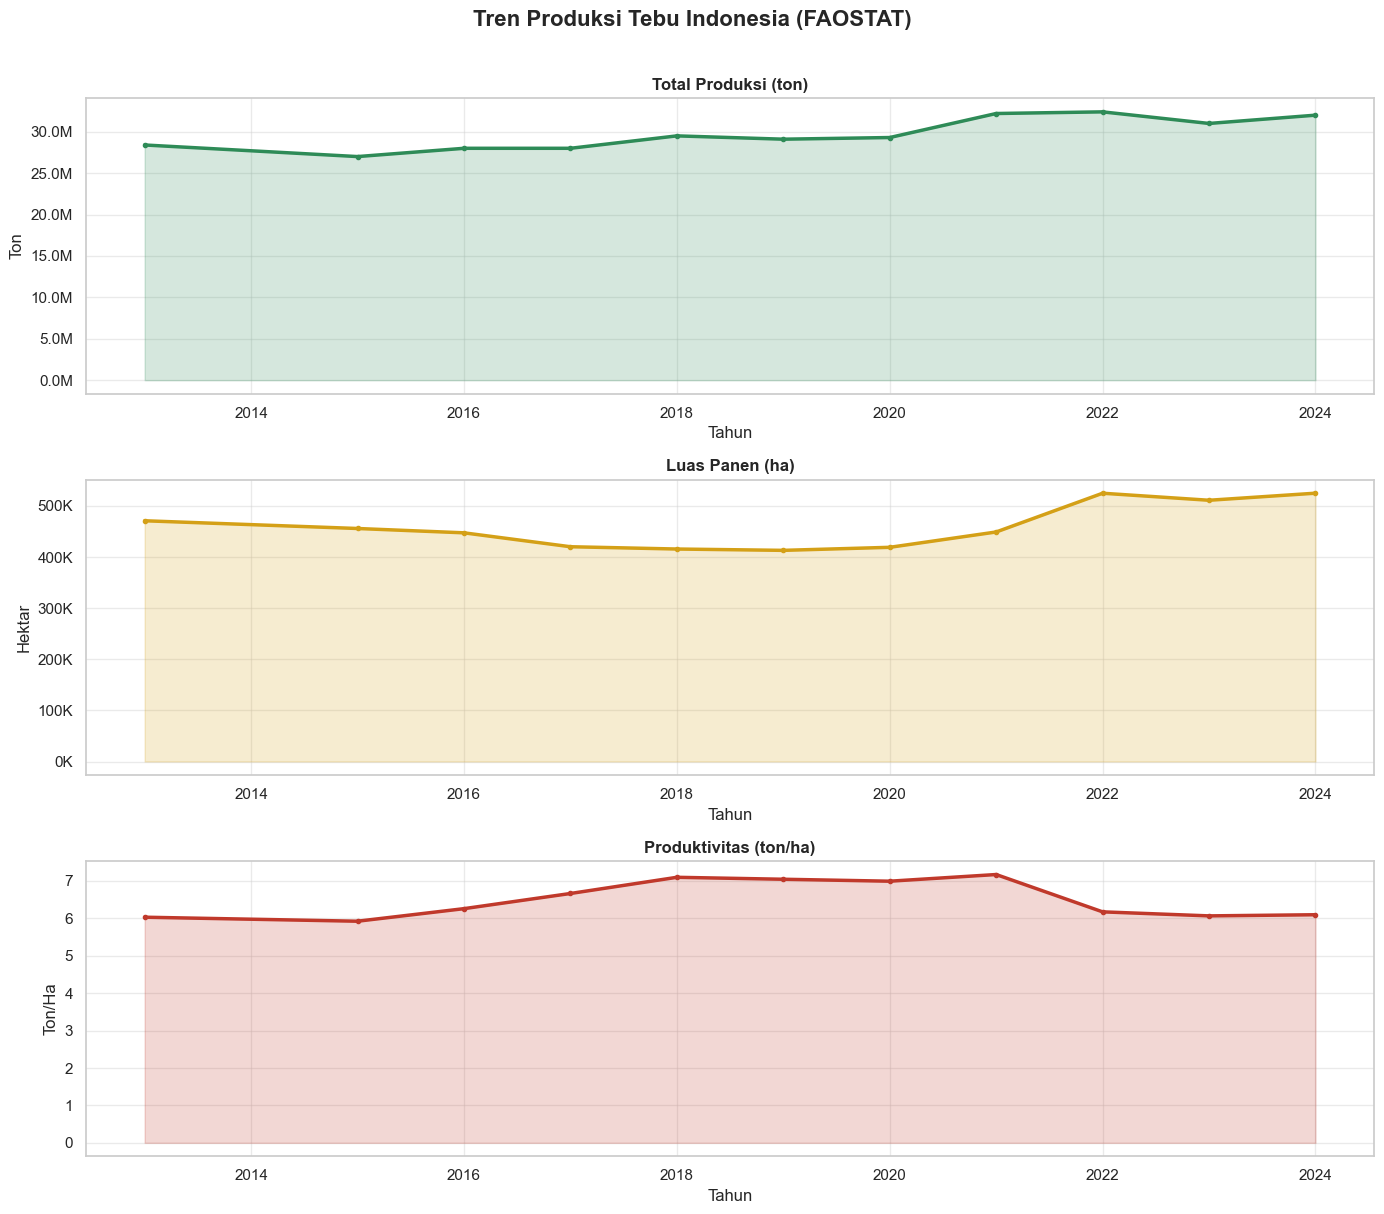

✅ Grafik disimpan ke output/figures/


In [30]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Tren Produksi Tebu Indonesia (FAOSTAT)', fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Produksi (ton)
axes[0].plot(fao_pivot['Year'], fao_pivot['produksi_ton'], color='#2e8b57', linewidth=2.5, marker='o', markersize=3)
axes[0].fill_between(fao_pivot['Year'], fao_pivot['produksi_ton'], alpha=0.2, color='#2e8b57')
axes[0].set_title('Total Produksi (ton)', fontweight='bold')
axes[0].set_ylabel('Ton')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Plot 2: Luas Panen (ha)
axes[1].plot(fao_pivot['Year'], fao_pivot['luas_panen_ha'], color='#d4a017', linewidth=2.5, marker='o', markersize=3)
axes[1].fill_between(fao_pivot['Year'], fao_pivot['luas_panen_ha'], alpha=0.2, color='#d4a017')
axes[1].set_title('Luas Panen (ha)', fontweight='bold')
axes[1].set_ylabel('Hektar')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Plot 3: Produktivitas (ton/ha)
if 'produktivitas_ton_ha' in fao_pivot.columns:
    axes[2].plot(fao_pivot['Year'], fao_pivot['produktivitas_ton_ha'], color='#c0392b', linewidth=2.5, marker='o', markersize=3)
    axes[2].fill_between(fao_pivot['Year'], fao_pivot['produktivitas_ton_ha'], alpha=0.2, color='#c0392b')
    axes[2].set_title('Produktivitas (ton/ha)', fontweight='bold')
    axes[2].set_ylabel('Ton/Ha')

for ax in axes:
    ax.set_xlabel('Tahun')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../output/figures/01_tren_produksi_historis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan ke output/figures/')

### 3.2 Analisis Dekade — Rata-rata Produksi per Periode

In [31]:
# Bagi data ke periode per dekade
fao_pivot['dekade'] = (fao_pivot['Year'] // 10) * 10

dekade_summary = fao_pivot.groupby('dekade').agg({
    'produksi_ton': 'mean',
    'luas_panen_ha': 'mean',
    'produktivitas_ton_ha': 'mean'
}).reset_index()

dekade_summary.columns = ['Dekade', 'Rata2 Produksi (ton)', 'Rata2 Luas Panen (ha)', 'Rata2 Produktivitas (ton/ha)']
dekade_summary['Rata2 Produksi (ton)'] = dekade_summary['Rata2 Produksi (ton)'].map('{:,.0f}'.format)
dekade_summary['Rata2 Luas Panen (ha)'] = dekade_summary['Rata2 Luas Panen (ha)'].map('{:,.0f}'.format)

print('📊 Ringkasan Per Dekade:')
dekade_summary

📊 Ringkasan Per Dekade:


,Dekade,Rata2 Produksi (ton),Rata2 Luas Panen (ha),Rata2 Produktivitas (ton/ha)
0,2010,"28,333,333","437,162",6.503248
1,2020,"31,380,000","485,748",6.500106


### 3.3 Deteksi Anomali / Tahun dengan Penurunan Drastis

In [32]:
# Hitung perubahan year-over-year
fao_pivot['produksi_yoy_pct'] = fao_pivot['produksi_ton'].pct_change() * 100

# Tahun dengan penurunan > 5%
penurunan = fao_pivot[fao_pivot['produksi_yoy_pct'] < -5][['Year', 'produksi_ton', 'produksi_yoy_pct']]
print('📉 Tahun dengan penurunan produksi > 5%:')
print(penurunan.to_string(index=False))

# Tahun dengan kenaikan > 10%
kenaikan = fao_pivot[fao_pivot['produksi_yoy_pct'] > 10][['Year', 'produksi_ton', 'produksi_yoy_pct']]
print('\n📈 Tahun dengan kenaikan produksi > 10%:')
print(kenaikan.to_string(index=False))

📉 Tahun dengan penurunan produksi > 5%:
Empty DataFrame
Columns: [Year, produksi_ton, produksi_yoy_pct]
Index: []

📈 Tahun dengan kenaikan produksi > 10%:
Empty DataFrame
Columns: [Year, produksi_ton, produksi_yoy_pct]
Index: []


## 🔮 4. Forecasting Produksi Tebu

- **SARIMA** — model statistik klasik untuk time series


In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('✅ Library forecasting siap!')

✅ Library forecasting siap!


### 4.1 Cek Stasioneritas Data (ADF Test)

In [34]:
# Data yang akan diprediksi
ts_data = fao_pivot.set_index('Year')['produksi_ton'].dropna()

# Augmented Dickey-Fuller Test
adf_result = adfuller(ts_data)

print('📊 Hasil ADF Test:')
print(f'  ADF Statistic : {adf_result[0]:.4f}')
print(f'  p-value       : {adf_result[1]:.4f}')
print(f'  Critical Values:')
for key, value in adf_result[4].items():
    print(f'    {key}: {value:.4f}')

if adf_result[1] < 0.05:
    print('\n✅ Data STASIONER (p < 0.05) — bisa langsung dipakai untuk ARIMA')
else:
    print('\n⚠️ Data TIDAK stasioner (p >= 0.05) — perlu differencing (d=1 atau d=2)')

📊 Hasil ADF Test:
  ADF Statistic : 0.4901
  p-value       : 0.9846
  Critical Values:
    1%: -4.9387
    5%: -3.4776
    10%: -2.8439

⚠️ Data TIDAK stasioner (p >= 0.05) — perlu differencing (d=1 atau d=2)


### 4.2 Split Data Train & Test

In [35]:
# Gunakan 80% untuk training, 20% untuk testing
split_idx = int(len(ts_data) * 0.8)
train = ts_data.iloc[:split_idx]
test  = ts_data.iloc[split_idx:]

print(f'Train: {train.index.min()} - {train.index.max()} ({len(train)} tahun)')
print(f'Test : {test.index.min()} - {test.index.max()} ({len(test)} tahun)')

Train: 2013 - 2021 (8 tahun)
Test : 2022 - 2024 (3 tahun)


### 4.3 Fitting Model SARIMA

In [36]:
# Model SARIMA(1,1,1) — sesuaikan order jika diperlukan
# p=1 (AR), d=1 (differencing), q=1 (MA)
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),  # Tidak ada seasonal (data tahunan)
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:           produksi_ton   No. Observations:                    8
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 -75.782
Date:                Sat, 14 Mar 2026   AIC                            157.565
Time:                        12:02:50   BIC                            156.393
Sample:                             0   HQIC                           154.420
                                  - 8                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0786      0.009     -8.427      0.000      -0.097      -0.060
ma.L1         -3.6098      1.341     -2.691      0.007      -6.239      -0.980
sigma2      1.549e+12   3.85e-13   4.03e+24      0.0

### 4.4 Evaluasi Model pada Data Test

In [37]:
# Prediksi pada data test
pred_test = result.forecast(steps=len(test))
pred_test.index = test.index

# Hitung error metrics
mae  = mean_absolute_error(test, pred_test)
rmse = np.sqrt(mean_squared_error(test, pred_test))
mape = np.mean(np.abs((test - pred_test) / test)) * 100

print('📊 Evaluasi Model:')
print(f'  MAE  : {mae:,.0f} ton')
print(f'  RMSE : {rmse:,.0f} ton')
print(f'  MAPE : {mape:.2f}%')

if mape < 10:
    print('\n✅ Akurasi BAIK (MAPE < 10%)')
elif mape < 20:
    print('\n⚠️ Akurasi CUKUP (MAPE 10-20%)')
else:
    print('\n❌ Akurasi KURANG (MAPE > 20%) — coba adjust order SARIMA')

📊 Evaluasi Model:
  MAE  : 767,587 ton
  RMSE : 891,190 ton
  MAPE : 2.39%

✅ Akurasi BAIK (MAPE < 10%)


### 4.5 Prediksi 10 Tahun ke Depan

In [38]:
# Refit model dengan seluruh data
model_full = SARIMAX(
    ts_data,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Prediksi 10 tahun ke depan
n_forecast = 10
forecast = model_full.get_forecast(steps=n_forecast)
forecast_mean = forecast.predicted_mean
forecast_ci   = forecast.conf_int(alpha=0.05)  # 95% confidence interval

# Buat index tahun prediksi
last_year = ts_data.index.max()
forecast_years = range(last_year + 1, last_year + n_forecast + 1)
forecast_mean.index = forecast_years
forecast_ci.index   = forecast_years

print('🔮 Prediksi Produksi Tebu Indonesia:')
forecast_result = pd.DataFrame({
    'Tahun': forecast_years,
    'Prediksi (ton)': forecast_mean.values,
    'Batas Bawah (ton)': forecast_ci.iloc[:, 0].values,
    'Batas Atas (ton)': forecast_ci.iloc[:, 1].values
})
forecast_result['Prediksi (ton)'] = forecast_result['Prediksi (ton)'].map('{:,.0f}'.format)
forecast_result

🔮 Prediksi Produksi Tebu Indonesia:


,Tahun,Prediksi (ton),Batas Bawah (ton),Batas Atas (ton)
0,2025,"31,866,637",2.927834e+07,3.445493e+07
1,2026,"31,829,407",2.850173e+07,3.515708e+07
2,2027,"31,819,014",2.796069e+07,3.567733e+07
3,2028,"31,816,112",2.750913e+07,3.612310e+07
4,2029,"31,815,302",2.710655e+07,3.652405e+07
5,2030,"31,815,076",2.673737e+07,3.689278e+07
6,2031,"31,815,013",2.639370e+07,3.723632e+07
7,2032,"31,814,995",2.607067e+07,3.755932e+07
8,2033,"31,814,990",2.576489e+07,3.786509e+07
9,2034,"31,814,989",2.547385e+07,3.815612e+07


### 4.6 Visualisasi Prediksi

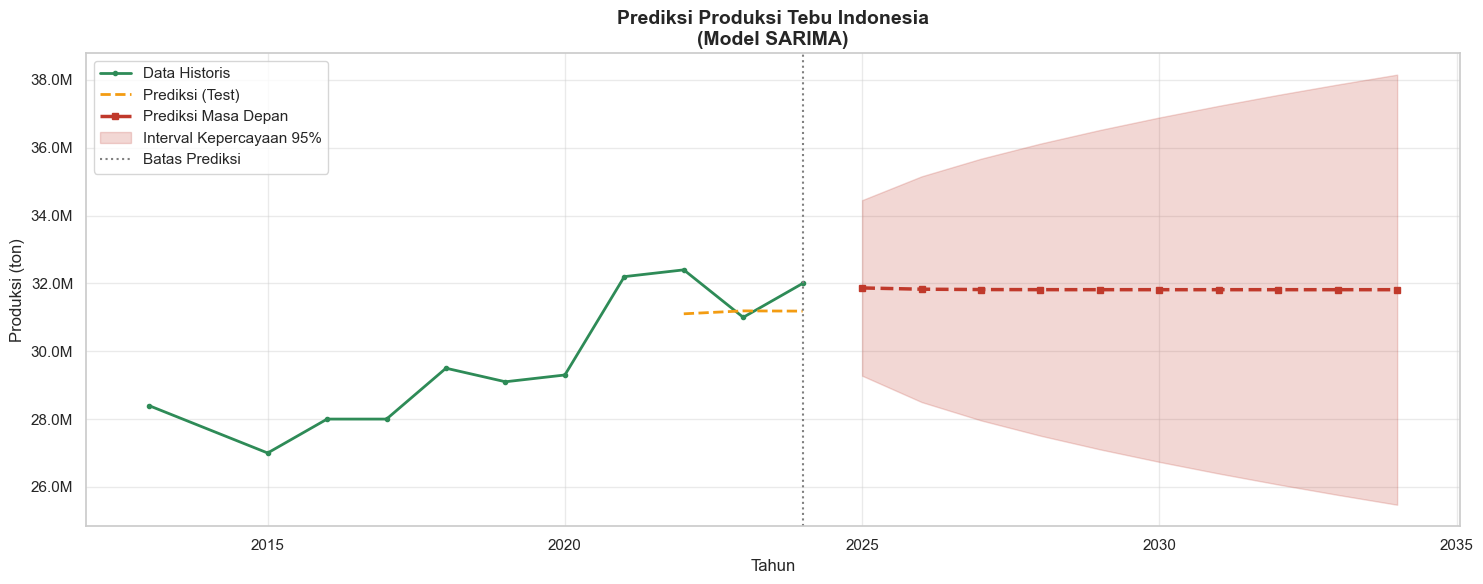

✅ Grafik prediksi disimpan!


In [39]:
fig, ax = plt.subplots(figsize=(15, 6))

# Data historis
ax.plot(ts_data.index, ts_data.values, label='Data Historis',
        color='#2e8b57', linewidth=2, marker='o', markersize=3)

# Data test vs prediksi
ax.plot(test.index, pred_test.values, label='Prediksi (Test)',
        color='#f39c12', linewidth=2, linestyle='--')

# Prediksi masa depan
ax.plot(list(forecast_years), forecast_mean.values, label='Prediksi Masa Depan',
        color='#c0392b', linewidth=2.5, linestyle='--', marker='s', markersize=5)

# Confidence interval
ax.fill_between(
    list(forecast_years),
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2, color='#c0392b', label='Interval Kepercayaan 95%'
)

# Garis pemisah historis vs prediksi
ax.axvline(x=last_year, color='gray', linestyle=':', linewidth=1.5, label='Batas Prediksi')

ax.set_title('Prediksi Produksi Tebu Indonesia\n(Model SARIMA)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('Produksi (ton)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../output/figures/02_prediksi_produksi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik prediksi disimpan!')

## 💾 5. Simpan Data

In [42]:
fao_pivot.to_csv('../data/processed/faostat_indonesia_cleaned.csv', index=False)
print('✅ Data FAOSTAT tersimpan ke processed/')

✅ Data FAOSTAT tersimpan ke processed/


## 6. Kesimpulan

- Model "melihat" bahwa pertumbuhan di 2020-an tidak secepat sebelumnya, sehingga prediksinya konservatif. Ini justru jujur secara statistik, dan sesuai dengan temuan bahwa produktivitas stagnan di 6,50 ton/ha.

**Temuan utama:**
- Produksi naik 10.7% dari dekade 2010-an (28,3 jt ton) ke 2020-an (31,4 jt ton)
- Luas panen bertambah 48.586 ha — pertumbuhan didorong ekspansi lahan, bukan efisiensi
- Produktivitas stagnan di 6,50 ton/ha selama 10+ tahun — ini isu kritis yang menarik untuk diangkat ke PT. SGN
- Data stabil, tidak ada anomali drastis

**Prediksi 2025-2030**
- Produksi akan melandai di ~31,8 juta ton/tahun — sinyal plateau pertumbuhan

**Rekomendasi:**
- Fokus pada peningkatan produktivitas per hektar, diversifikasi produk turunan, dan integrasi data cuaca + harga untuk model yang lebih akurat

**Daftar Pustaka**
- Sumber datta diambil dari cakupan FAOSTAT, BPS (2 dataset), Outlook Tebu Kementan, dan Statistik Tebu Indonesia.
- Teori ARIMABox, G.E.P. & Jenkins, G.M. (1976). Time Series Analysis. Holden-Day.Implementasi PythonSeabold, S. & Perktold, J. (2010). Statsmodels. Proc. of SciPy Conference.ADF TestDickey, D.A. & Fuller, W.A. (1979). JASA, 74(366), 427–431.MAPE sebagai metrikMakridakis, S. (1993). International Journal of Forecasting, 9(4), 527–529.
---
*Notebook ini dibuat sebagai bagian dari portfolio data analyst — Reisha*